In [1]:
# ============================================
# Imports
# ============================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
import jax
import jax.numpy as jnp
import numpyro as pyro
import numpyro.distributions as dist
from numpyro.diagnostics import hpdi

# Disable JAX warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")


/home/vishu/stt/hbmep/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
import logging

import numpy as np
import jax
import jax.numpy as jnp
import numpyro as pyro
import numpyro.distributions as dist

from hbmep import functional as F, smooth_functional as SF
from hbmep.model import BaseModel
from hbmep.util import site

EPS = 1e-3


class HB(BaseModel):
    def __init__(self, *args, **kw):
        super(HB, self).__init__(*args, **kw)
        self.use_mixture = False

    def hb_rl(self, intensity, features, response=None, **kw):
        num_data = intensity.shape[0]
        num_features = np.max(features, axis=0) + 1

        # Mask missing observations
        mask_obs = True
        if response is not None:
            mask_obs = np.invert(np.isnan(response))

        # Hyper-priors
        a_loc = pyro.sample(
            site.a.log, dist.TruncatedNormal(5., 10., low=0)
        )
        a_scale = pyro.sample(site.a.scale, dist.HalfNormal(10.))
        b_scale = pyro.sample(site.b.scale, dist.HalfNormal(10.))
        h_scale = pyro.sample(site.h.scale, dist.HalfNormal(50.))

        g_scale = pyro.sample(site.g.scale, dist.HalfNormal(5.))
        v_scale = pyro.sample(site.v.scale, dist.HalfNormal(1.))

        c1_scale = pyro.sample(site.c1.scale, dist.HalfNormal(5.))
        c2_scale = pyro.sample(site.c2.scale, dist.HalfNormal(.5))

        # Priors
        with pyro.plate(site.num_response, self.num_response):
            with pyro.plate_stack(
                site.num_features, num_features, rightmost_dim=-2
            ):
                a = pyro.sample(
                    site.a, dist.TruncatedNormal(a_loc, a_scale, low=0)
                )

                b_raw = pyro.sample(site.b.raw, dist.HalfNormal(1))
                b = pyro.deterministic(site.b, b_scale * b_raw)

                g_raw = pyro.sample(site.g.raw, dist.HalfNormal(1))
                g = pyro.deterministic(site.g, g_scale * g_raw)

                h_raw = pyro.sample(site.h.raw, dist.HalfNormal(1))
                h = pyro.deterministic(site.h, h_scale * h_raw)

                v_raw = pyro.sample(site.v.raw, dist.HalfNormal(1))
                v = pyro.deterministic(site.v, v_scale * v_raw)

                c1_raw = pyro.sample(site.c1.raw, dist.HalfNormal(1))
                c1 = pyro.deterministic(site.c1, c1_scale * c1_raw)

                c2_raw = pyro.sample(site.c2.raw, dist.HalfNormal(1))
                c2 = pyro.deterministic(site.c2, c2_scale * c2_raw)

        # Outlier probability
        if self.use_mixture:
            q = pyro.sample(site.outlier_prob, dist.Uniform(0., 0.01))

        # Observation model
        with pyro.handlers.mask(mask=mask_obs):
            with pyro.plate(site.num_response, self.num_response):
                with pyro.plate(site.num_data, num_data):
                    mu = SF.rectified_logistic(
                        intensity,
                        a[*features.T],
                        b[*features.T],
                        g[*features.T],
                        h[*features.T],
                        v[*features.T],
                        EPS
                    )
                    alpha, beta = self.gamma_likelihood(
                        mu, 
                        c1[*features.T],
                        c2[*features.T],
                    )
                    pyro.deterministic(site.mu, mu)

                    # Mixture distribution
                    if self.use_mixture:
                        mixing_distribution = dist.Categorical(
                            probs=jnp.stack([1 - q, q], axis=-1)
                        )
                        component_distributions=[
                            dist.Gamma(concentration=alpha, rate=beta),
                            dist.HalfNormal(
                                scale=(g[*features.T] + h[*features.T])
                            )
                        ]
                        Mixture = dist.MixtureGeneral(
                            mixing_distribution=mixing_distribution,
                            component_distributions=component_distributions
                        )

                    # Observations
                    y_ = pyro.sample(
                        site.obs,
                        (
                            Mixture if self.use_mixture
                            else dist.Gamma(concentration=alpha, rate=beta)
                        ),
                        obs=response
                    )


In [4]:
csv_path = "/home/vishu/sc_ramp.csv"
df = pd.read_csv(csv_path)
req_cols = ["sc_current", "FCR", "participant", "recr_curve"]
df = df.dropna(subset=req_cols).copy()

group_cols = ["participant", "recr_curve"]


In [5]:
#Run hbMEP Bayesian Model

model = HB()
model.intensity = "sc_current"
model.features = group_cols
model.response = ["FCR"]
model._model = model.hb_rl
model.use_mixture = True
model.mcmc_params = dict(num_chains=2, num_warmup=1000, num_samples=1000) # Only way to determine is by analyzing convergence diagnostics. 

# Encode and run
df_enc, enc = model.load(df)
mcmc, posterior = model.run(df=df_enc)



Running chain 1: 100%|██████████| 2000/2000 [00:58<00:00, 34.08it/s]


In [6]:
pred_df = model.make_prediction_dataset(df=df_enc, num_points=200)
predictive = model.predict(df=pred_df, posterior=posterior)


In [7]:
print(type(predictive))
print(predictive.keys())


<class 'dict'>
dict_keys(['b', 'c₁', 'c₂', 'g', 'h', 'obs', 'v', 'µ'])


In [8]:
posterior[site.a].shape

(2000, 4, 9, 1)

In [ ]:
model.features

['participant', 'recr_curve']

In [8]:
combination = (1, 3)
print(enc[model.features[0]].inverse_transform([combination[0]])[0])
print(enc[model.features[1]].inverse_transform([combination[1]])[0])


s109
scramp-004


In [10]:
a = posterior[site.a]
print(a.shape)

mu = predictive[site.mu]
print(mu.shape)

mu_hdi = hpdi(mu, axis=0, prob=.95)
print(mu_hdi.shape)

obs = predictive[site.obs]
print(obs.shape)

obs_hdi = hpdi(obs, axis=0, prob=.95)
print(obs_hdi.shape)


(2000, 4, 9, 1)
(2000, 5000, 1)
(2, 5000, 1)
(2000, 5000, 1)
(2, 5000, 1)


In [11]:
idx = df_enc[model.features].apply(tuple, axis=1).isin([combination])
df_temp = df_enc[idx].reset_index(drop=True).copy()
print(df_temp.shape)


(44, 38)


In [13]:
idx = pred_df[model.features].apply(tuple, axis=1).isin([combination])
pred_df_temp = pred_df[idx].reset_index(drop=True).copy()
print(pred_df_temp.shape)

mu_temp = mu[:, idx, ...]
print(mu_temp.shape)

mu_temp_hdi = mu_hdi[:, idx, ...]
print(mu_temp_hdi.shape)

obs_temp_hdi = obs_hdi[:, idx, ...]
print(obs_temp_hdi.shape)


(200, 3)
(2000, 200, 1)
(2, 200, 1)
(2, 200, 1)


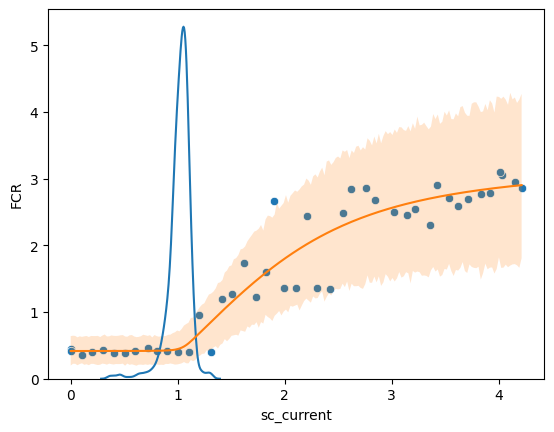

In [14]:
sns.scatterplot(df_temp, x=model.intensity, y=model.response[0])
sns.kdeplot(a[:, *combination, 0])
sns.lineplot(x=pred_df_temp[model.intensity], y=mu_temp.mean(axis=0)[:, 0])
# plt.fill_between(pred_df_temp[model.intensity], mu_temp_hdi[0, ..., 0], mu_temp_hdi[1, ..., 0], alpha=.2)
plt.fill_between(pred_df_temp[model.intensity], obs_temp_hdi[0, ..., 0], obs_temp_hdi[1, ..., 0], alpha=.2)
# sns.kdeplot(a[:, 0, 2, 0])

(2000, 1088, 1)